In [1]:
from skimage.segmentation import slic
from skimage.data import astronaut
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb
import cv2

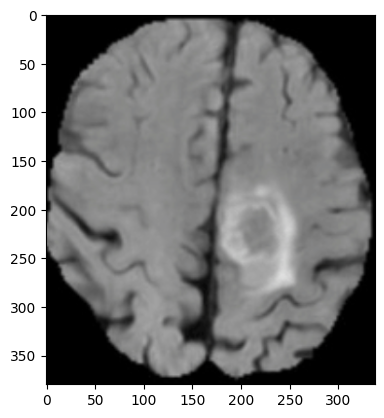

In [2]:
# image_path = 'images/Image3.jpg'
image_path = 'images/flair.png'
image = cv2.imread(image_path)
# image = cv2.resize(image, (500,500))

plt.imshow(image)
plt.show()

## SLIC

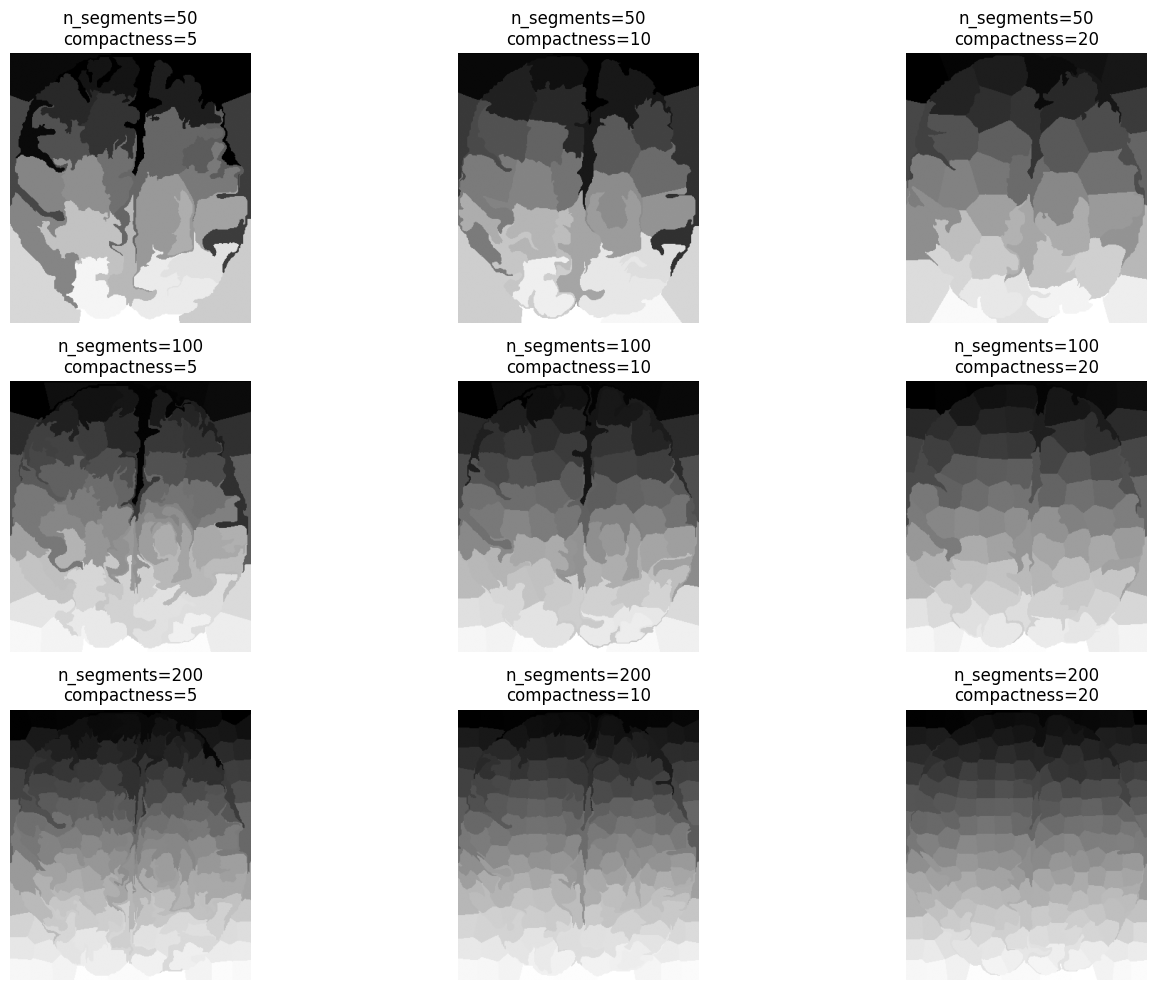

In [3]:
n_seg = [50, 100, 200]
comps = [5, 10, 20]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, n in enumerate(n_seg):
    for j, comp in enumerate(comps):
        segments = slic(image, n_segments=n, compactness=comp)
        
        ax = axs[i, j]
        ax.imshow(segments, cmap='gray')
        ax.set_title(f'n_segments={n}\ncompactness={comp}')
        ax.axis('off')

plt.tight_layout()
plt.show()

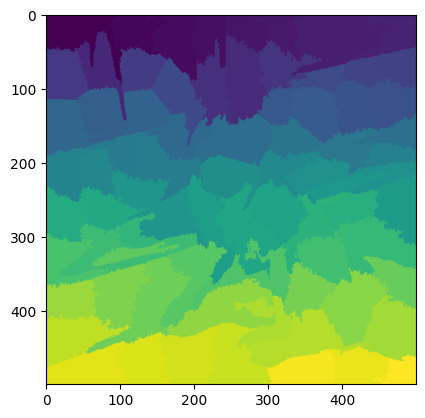

In [20]:
segments = slic(image, n_segments=100, compactness=10)

plt.imshow(segments)
plt.show()

## Felzenszwalb

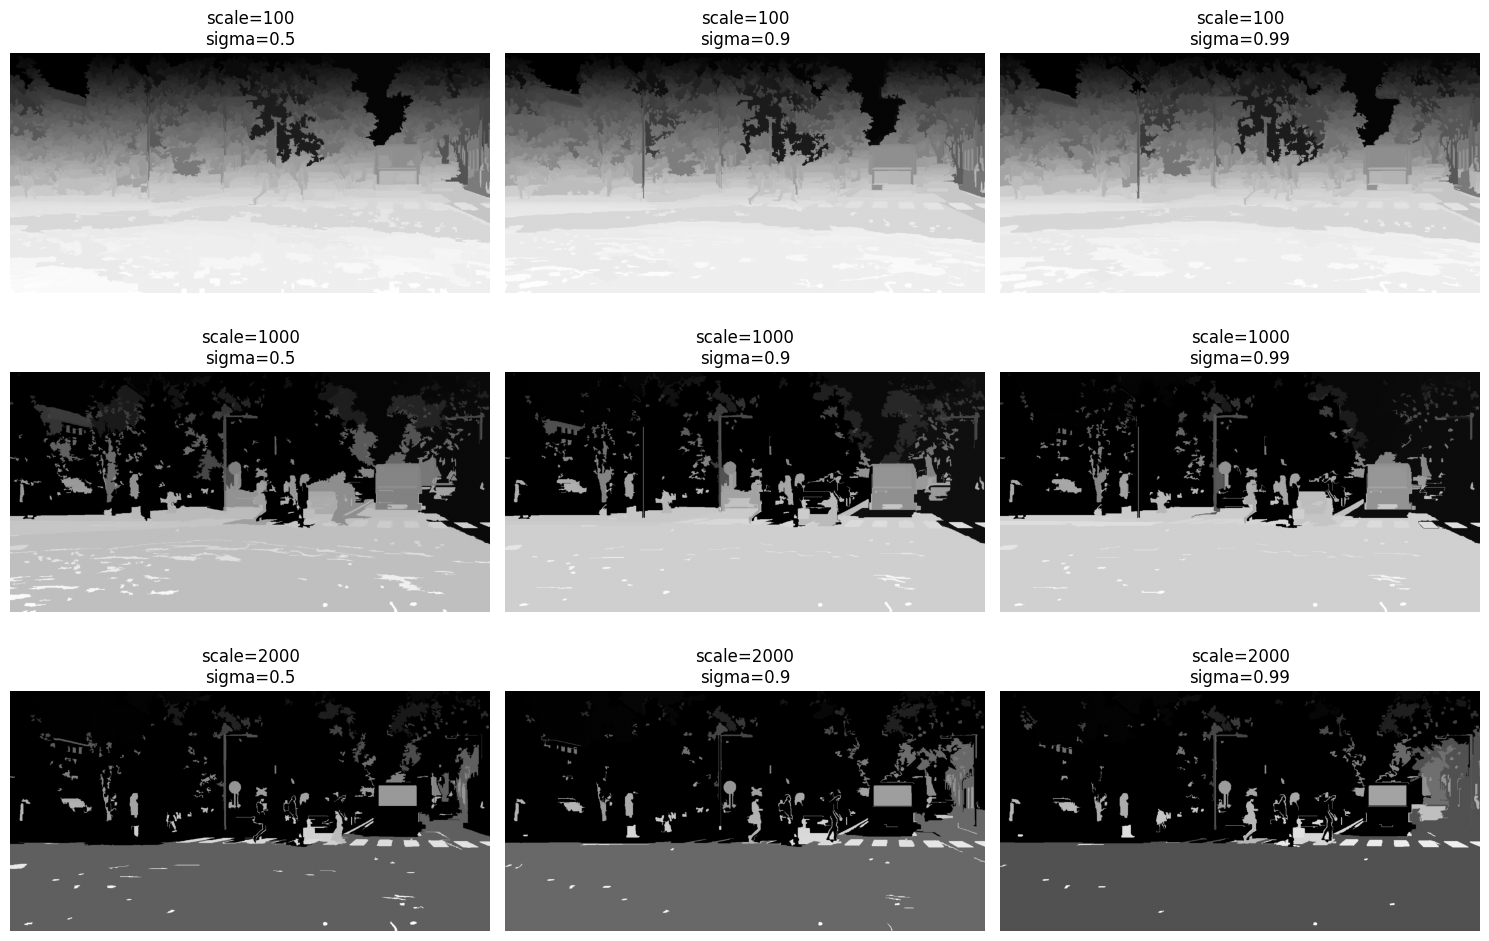

In [45]:
scales = [100, 1000, 2000]
sigmas = [0.5, 0.9, 0.99]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, scale in enumerate(scales):
    for j, sigma in enumerate(sigmas):
        segments = felzenszwalb(image, scale=scale, sigma=sigma, min_size=50)
        
        ax = axs[i, j]
        ax.imshow(segments, cmap='gray')
        ax.set_title(f'scale={scale}\nsigma={sigma}')
        ax.axis('off')

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Scale=100, Sigma=0.5:
  - Unique segments: 2507
  - Initial boxes: 2075
  - After NMS: 1827



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Scale=100, Sigma=0.9:
  - Unique segments: 2253
  - Initial boxes: 1808
  - After NMS: 1517



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


...

Scale=2000, Sigma=0.5:
  - Unique segments: 264
  - Initial boxes: 230
  - After NMS: 225



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Scale=2000, Sigma=0.9:
  - Unique segments: 205
  - Initial boxes: 182
  - After NMS: 180



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Scale=2000, Sigma=0.99:
  - Unique segments: 200
  - Initial boxes: 178
  - After NMS: 175



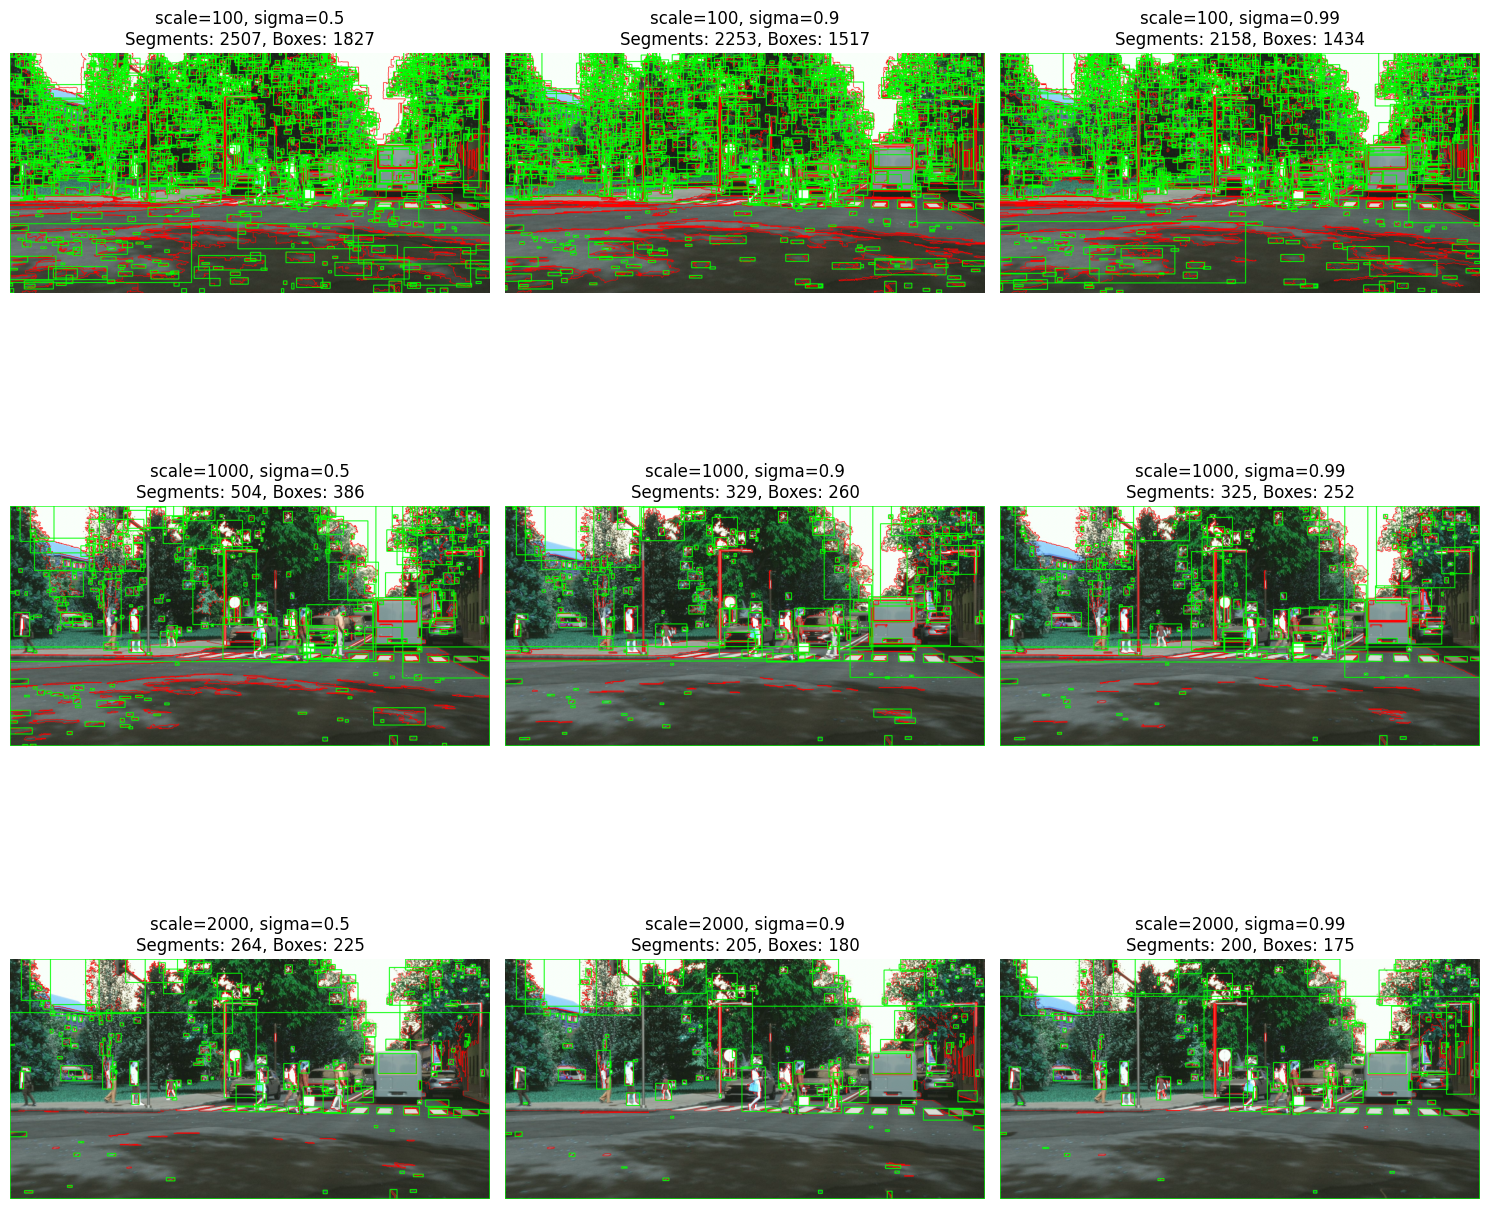

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb
from skimage.measure import regionprops
import cv2

# Assuming 'image' is already loaded
# If using a color image, we might want to convert it for display
image_rgb = image if len(image.shape) == 3 else cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

scales = [100, 1000, 2000]
sigmas = [0.5, 0.9, 0.99]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

def generate_bounding_boxes(segments):
    """Generate bounding boxes from segmentation mask"""
    boxes = []
    segment_ids = np.unique(segments)
    
    for seg_id in segment_ids:
        # Create binary mask for this segment
        mask = (segments == seg_id)
        
        # Find coordinates of the segment
        rows = np.any(mask, axis=1)
        cols = np.any(mask, axis=0)
        
        if np.any(rows) and np.any(cols):
            ymin, ymax = np.where(rows)[0][[0, -1]]
            xmin, xmax = np.where(cols)[0][[0, -1]]
            
            # Calculate area and aspect ratio for filtering
            area = (ymax - ymin) * (xmax - xmin)
            aspect_ratio = (xmax - xmin) / max(ymax - ymin, 1)
            
            # Filter out very small or very elongated regions
            if area > 50 and 0.2 < aspect_ratio < 5:
                boxes.append([xmin, ymin, xmax, ymax, area])
    
    return boxes

def non_max_suppression(boxes, overlap_thresh=0.5):
    """Apply non-maximum suppression to bounding boxes"""
    if len(boxes) == 0:
        return []
    
    # Convert to numpy array
    boxes = np.array(boxes)
    
    # Extract coordinates and scores (using area as score)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    scores = boxes[:, 4]
    
    # Initialize list of picked indices
    picked = []
    
    # Sort boxes by score (descending)
    idxs = np.argsort(scores)[::-1]
    
    while len(idxs) > 0:
        # Grab the highest scoring box
        i = idxs[0]
        picked.append(i)
        
        if len(idxs) == 1:
            break
        
        # Compute IoU between the picked box and the rest
        xx1 = np.maximum(x1[i], x1[idxs[1:]])
        yy1 = np.maximum(y1[i], y1[idxs[1:]])
        xx2 = np.minimum(x2[i], x2[idxs[1:]])
        yy2 = np.minimum(y2[i], y2[idxs[1:]])
        
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        
        intersection = w * h
        area1 = (x2[i] - x1[i] + 1) * (y2[i] - y1[i] + 1)
        area2 = (x2[idxs[1:]] - x1[idxs[1:]] + 1) * (y2[idxs[1:]] - y1[idxs[1:]] + 1)
        
        iou = intersection / (area1 + area2 - intersection)
        
        # Keep boxes with IoU less than threshold
        keep_idxs = np.where(iou < overlap_thresh)[0]
        idxs = idxs[keep_idxs + 1]
    
    return boxes[picked]

for i, scale in enumerate(scales):
    for j, sigma in enumerate(sigmas):
        # Perform segmentation
        segments = felzenszwalb(image, scale=scale, sigma=sigma, min_size=50)
        
        # Generate bounding boxes from segments
        boxes = generate_bounding_boxes(segments)
        
        # Apply non-maximum suppression
        final_boxes = non_max_suppression(boxes, overlap_thresh=0.3)
        
        # Create visualization
        ax = axs[i, j]
        
        # Show original image with segmentation overlay
        overlay = image_rgb.copy()
        
        # Draw segmentation boundaries (optional)
        from skimage.segmentation import mark_boundaries
        if len(image.shape) == 3:
            overlay = mark_boundaries(overlay, segments, color=(1, 0, 0), mode='outer')
        
        # Draw final bounding boxes
        for box in final_boxes:
            xmin, ymin, xmax, ymax, _ = box.astype(int)
            cv2.rectangle(overlay, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        
        ax.imshow(overlay)
        ax.set_title(f'scale={scale}, sigma={sigma}\nSegments: {len(np.unique(segments))}, Boxes: {len(final_boxes)}')
        ax.axis('off')
        
        # Print statistics for this parameter set
        print(f"Scale={scale}, Sigma={sigma}:")
        print(f"  - Unique segments: {len(np.unique(segments))}")
        print(f"  - Initial boxes: {len(boxes)}")
        print(f"  - After NMS: {len(final_boxes)}")
        print()

plt.tight_layout()
plt.show()

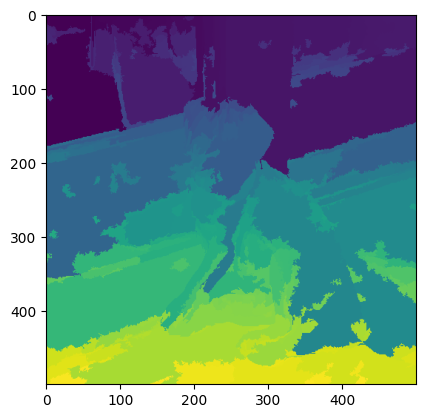

In [ ]:
segments_fz = felzenszwalb(image, scale=100, sigma=0.5, min_size=50)

plt.imshow(segments_fz)
plt.show()